# Pooling Ablation For RNN User Embeddings

В этом ноутбуке проверяется, как способ агрегации hidden states влияет на качество пользовательских эмбеддингов. `GRU` выдаёт скрытое состояние на каждом шаге последовательности, поэтому один user embedding можно получить несколькими способами: взять последнее состояние, усреднить все состояния, взять покоординатный максимум или склеить последнее состояние со средним.

Это не просто технический перебор гиперпараметра. Для темы курсовой это отдельный исследовательский вопрос: какой способ превращения последовательностного encoder'а в фиксированный пользовательский вектор лучше сохраняет поведенческую информацию.

## План

1. Загрузить подготовленные последовательности, split, labels и обученный `GRU` encoder.
2. Построить prefix-based embeddings для `last`, `mean`, `max`, `last_mean` pooling при `PREFIX_LEN=150`.
3. Сравнить стратегии через одинаковую downstream-валидацию: `Embedding only` и `Baseline + Embedding` для `retention_7d` и `retention_14d`.
4. Дополнительно сравнить embedding spaces через нормы, PCA explained variance и KMeans-профили.
5. Сохранить результаты в `artifacts/pooling_ablation/`.

In [1]:
from pathlib import Path
import json
import os
import sys

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '8')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import torch

PROJECT_ROOT = Path('/Users/fedornikonov/hse_recsys_rnn')
sys.path.append(str(PROJECT_ROOT))

from src.data import load_prepared_sequences
from src.downstream import (
    build_base_meta,
    build_baseline_features,
    build_meta_for_prefix,
    evaluate_xgboost_feature_set,
)
from src.embedding_analysis import add_embedding_norm, embedding_columns, fit_kmeans, pca_projection, cluster_profile, build_activity_bucket
from src.models import GRUEncoder
from src.pooling import build_user_embeddings_with_pooling, SUPPORTED_POOLING
from src.splits import apply_user_split, load_user_split
from src.train import choose_device, seed_everything

sns.set_theme(style='whitegrid', context='notebook')
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)

def to_pandas(df: pl.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(df.to_dicts())

DATA_DIR = PROJECT_ROOT / 'artifacts/data'
RNN_DIR = PROJECT_ROOT / 'artifacts/rnn'
OUT_DIR = PROJECT_ROOT / 'artifacts/pooling_ablation'
FIGURES_DIR = OUT_DIR / 'figures'
EMBEDDINGS_DIR = OUT_DIR / 'embeddings'
for path in [OUT_DIR, FIGURES_DIR, EMBEDDINGS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
PREFIX_LEN = 150
TOP_K_EVENTS = 10
HORIZONS = {'retention_7d': 7, 'retention_14d': 14}
POOLING_STRATEGIES = ['last', 'mean', 'max', 'last_mean']
BATCH_SIZE = 512
N_CLUSTERS = 5

seed_everything(SEED)
device = choose_device()
print(f'device={device}, prefix_len={PREFIX_LEN}, pooling={POOLING_STRATEGIES}')

device=mps, prefix_len=150, pooling=['last', 'mean', 'max', 'last_mean']


## 1. Загрузка данных и модели

Используется тот же split и тот же `GRU` checkpoint, что в предыдущих экспериментах. Это важно: меняется только способ извлечения user embedding из hidden states, а не train/test protocol или сама обученная модель.

In [2]:
prepared = load_prepared_sequences(DATA_DIR)
split = load_user_split(DATA_DIR / 'split.json')
split_prepared = apply_user_split(prepared, split)
train_prepared = split_prepared['train']
split_users_df = pl.read_parquet(DATA_DIR / 'split_users.parquet')
sequences_df = pl.read_parquet(DATA_DIR / 'user_sequences.parquet')

config = json.loads((RNN_DIR / 'rnn_config.json').read_text(encoding='utf-8'))
checkpoint = torch.load(RNN_DIR / 'rnn_encoder.pt', map_location='cpu')
model = GRUEncoder(
    vocab_size=len(prepared.event2idx),
    event_dim=config['event_dim'],
    hidden_dim=config['hidden_dim'],
    num_layers=config['num_layers'],
    dropout=config['dropout'],
).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

setup_df = pl.DataFrame(
    {
        'parameter': ['users', 'vocab_size', 'event_dim', 'hidden_dim', 'num_layers', 'trained_max_len', 'prefix_len'],
        'value': [str(len(prepared.user_ids)), str(len(prepared.event2idx)), str(config['event_dim']), str(config['hidden_dim']), str(config['num_layers']), str(config['max_len']), str(PREFIX_LEN)],
    }
)
setup_df

parameter,value
str,str
"""users""","""52495"""
"""vocab_size""","""81"""
"""event_dim""","""64"""
"""hidden_dim""","""128"""
"""num_layers""","""1"""
"""trained_max_len""","""128"""
"""prefix_len""","""150"""


## 2. Prefix labels и baseline features

Labels и baseline-признаки строятся по той же no-leakage схеме, что в downstream-ноутбуке: признаки берутся из первых `PREFIX_LEN` событий, а retention labels проверяют наличие активности после горизонта `7` или `14` дней. Это нужно, чтобы pooling-стратегии сравнивались с уже существующим baseline честно.

In [3]:
base_meta_df, data_end_ts = build_base_meta(str(DATA_DIR / 'clean_events' / '*.parquet'), prepared.user_ids)
meta_df, label_summary_df = build_meta_for_prefix(
    base_meta_df,
    prefix_len=PREFIX_LEN,
    horizons=HORIZONS,
    data_end_ts=data_end_ts,
)
baseline_df, baseline_feature_cols, baseline_summary_df = build_baseline_features(
    prepared,
    train_prepared,
    split_users_df,
    meta_df,
    prefix_len=PREFIX_LEN,
    top_k_events=TOP_K_EVENTS,
    horizons=HORIZONS,
)
label_summary_df

prefix_len,label,valid_users,positive_rate
i64,str,i64,f64
150,"""retention_7d""",18547,0.281124
150,"""retention_14d""",15207,0.181758


### Вывод по prefix labels

Для `prefix_len=150` downstream-протокол остаётся достаточно строгим: в `test` доступны `2,805` пользователей для `retention_7d` и `2,303` для `retention_14d`. Это меньше полного числа пользователей, но именно такая фильтрация убирает утечку через неполные короткие истории.


In [4]:
baseline_summary_df

prefix_len,feature_group,num_features,top_events_used
i64,str,i64,str
150,"""baseline""",15,"""REWARD, machine_learning, Trai…"


## 3. Извлечение embeddings с разными pooling-стратегиями

Все стратегии используют один и тот же обученный `GRU`. Разница только в том, как hidden states по шагам последовательности сворачиваются в один вектор пользователя:

- `last`: последнее состояние `h_T`;
- `mean`: среднее по всем состояниям;
- `max`: покоординатный максимум;
- `last_mean`: конкатенация `last` и `mean`, поэтому размерность вектора становится `256` вместо `128`.

In [5]:
embedding_sets = {}
embedding_summary_rows = []

for strategy in POOLING_STRATEGIES:
    embeddings_df = build_user_embeddings_with_pooling(
        model,
        prepared,
        max_len=PREFIX_LEN,
        batch_size=BATCH_SIZE,
        device=device,
        pooling=strategy,
        take_last=False,
    ).join(split_users_df, on='appmetrica_device_id', how='inner')

    embedding_cols = embedding_columns(embeddings_df.columns)
    output_path = EMBEDDINGS_DIR / f'gru_pooling_{strategy}.parquet'
    embeddings_df.write_parquet(output_path)
    embedding_sets[strategy] = {
        'df': embeddings_df,
        'cols': embedding_cols,
        'path': output_path,
    }
    embedding_summary_rows.append(
        {
            'pooling': strategy,
            'num_users': embeddings_df.height,
            'embedding_dim': len(embedding_cols),
            'path': str(output_path.relative_to(PROJECT_ROOT)),
        }
    )

embedding_summary_df = pl.DataFrame(embedding_summary_rows)
embedding_summary_df.write_csv(OUT_DIR / 'pooling_embedding_summary.csv')
embedding_summary_df

pooling,num_users,embedding_dim,path
str,i64,i64,str
"""last""",52495,128,"""artifacts/pooling_ablation/emb…"
"""mean""",52495,128,"""artifacts/pooling_ablation/emb…"
"""max""",52495,128,"""artifacts/pooling_ablation/emb…"
"""last_mean""",52495,256,"""artifacts/pooling_ablation/emb…"


### Вывод по pooling embeddings

Все pooling-стратегии построены на одном и том же обученном `GRU`, поэтому различия дальше отражают именно способ агрегации hidden states, а не переобучение encoder. `last`, `mean` и `max` дают 128-мерные embeddings, а `last_mean` расширяет пространство до 256 признаков.


## 4. Downstream-проверка pooling strategies

Здесь downstream используется как внешняя проверка качества embeddings. Для каждой pooling-стратегии обучается одинаковый `XGBoost` на фиксированном split. Сравниваются три режима: только tabular baseline, только RNN embedding и baseline вместе с embedding.

In [6]:
metric_frames = []

for label_name in HORIZONS:
    baseline_metrics = evaluate_xgboost_feature_set(
        baseline_df,
        baseline_feature_cols,
        label_name,
        'Baseline',
        seed=SEED,
    ).with_columns([
        pl.lit('none').alias('pooling'),
        pl.lit(len(baseline_feature_cols)).alias('num_features'),
    ])
    metric_frames.append(baseline_metrics)

for strategy, bundle in embedding_sets.items():
    downstream_df = baseline_df.join(bundle['df'].drop('split'), on='appmetrica_device_id', how='inner')
    embedding_cols = bundle['cols']
    combined_cols = baseline_feature_cols + embedding_cols

    for label_name in HORIZONS:
        embedding_metrics = evaluate_xgboost_feature_set(
            downstream_df,
            embedding_cols,
            label_name,
            f'GRU {strategy}',
            seed=SEED,
        ).with_columns([
            pl.lit(strategy).alias('pooling'),
            pl.lit(len(embedding_cols)).alias('num_features'),
        ])
        combined_metrics = evaluate_xgboost_feature_set(
            downstream_df,
            combined_cols,
            label_name,
            f'Baseline + GRU {strategy}',
            seed=SEED,
        ).with_columns([
            pl.lit(strategy).alias('pooling'),
            pl.lit(len(combined_cols)).alias('num_features'),
        ])
        metric_frames.extend([embedding_metrics, combined_metrics])

pooling_metrics_df = (
    pl.concat(metric_frames)
    .with_columns(pl.lit(PREFIX_LEN).alias('prefix_len'))
    .select(['prefix_len', 'pooling', 'feature_set', 'label', 'split', 'roc_auc', 'pr_auc', 'num_users', 'num_features'])
    .sort(['label', 'split', 'pooling', 'feature_set'])
)
pooling_metrics_df.write_csv(OUT_DIR / 'pooling_downstream_metrics.csv')
pooling_metrics_df

prefix_len,pooling,feature_set,label,split,roc_auc,pr_auc,num_users,num_features
i32,str,str,str,str,f64,f64,i64,i32
150,"""last""","""Baseline + GRU last""","""retention_14d""","""test""",0.685828,0.34043,2303,143
150,"""last""","""GRU last""","""retention_14d""","""test""",0.686477,0.340033,2303,128
150,"""last_mean""","""Baseline + GRU last_mean""","""retention_14d""","""test""",0.68698,0.359179,2303,271
150,"""last_mean""","""GRU last_mean""","""retention_14d""","""test""",0.695125,0.34553,2303,256
150,"""max""","""Baseline + GRU max""","""retention_14d""","""test""",0.698173,0.362705,2303,143
150,"""max""","""GRU max""","""retention_14d""","""test""",0.702511,0.366277,2303,128
150,"""mean""","""Baseline + GRU mean""","""retention_14d""","""test""",0.697874,0.366251,2303,143
150,"""mean""","""GRU mean""","""retention_14d""","""test""",0.693713,0.360352,2303,128
150,"""none""","""Baseline""","""retention_14d""","""test""",0.683047,0.343962,2303,15


In [7]:
test_metrics_df = pooling_metrics_df.filter(pl.col('split') == 'test')
test_metrics_df

prefix_len,pooling,feature_set,label,split,roc_auc,pr_auc,num_users,num_features
i32,str,str,str,str,f64,f64,i64,i32
150,"""last""","""Baseline + GRU last""","""retention_14d""","""test""",0.685828,0.34043,2303,143
150,"""last""","""GRU last""","""retention_14d""","""test""",0.686477,0.340033,2303,128
150,"""last_mean""","""Baseline + GRU last_mean""","""retention_14d""","""test""",0.68698,0.359179,2303,271
150,"""last_mean""","""GRU last_mean""","""retention_14d""","""test""",0.695125,0.34553,2303,256
150,"""max""","""Baseline + GRU max""","""retention_14d""","""test""",0.698173,0.362705,2303,143
150,"""max""","""GRU max""","""retention_14d""","""test""",0.702511,0.366277,2303,128
150,"""mean""","""Baseline + GRU mean""","""retention_14d""","""test""",0.697874,0.366251,2303,143
150,"""mean""","""GRU mean""","""retention_14d""","""test""",0.693713,0.360352,2303,128
150,"""none""","""Baseline""","""retention_14d""","""test""",0.683047,0.343962,2303,15


### Вывод по downstream pooling ablation

`last` pooling больше не является явным провалом, но лучшие результаты даёт не он. На `test` для `retention_7d` сильнее всего по ROC-AUC чистый `GRU max` (`0.6827`), а по PR-AUC — чистый `GRU mean` (`0.4812`). Для `retention_14d` лучший ROC-AUC и PR-AUC в блоке у чистого `GRU max` (`0.7025` и `0.3663`). Значит, выбор pooling реально влияет на downstream, причём на новом split `max` стал самым сильным single-embedding вариантом.


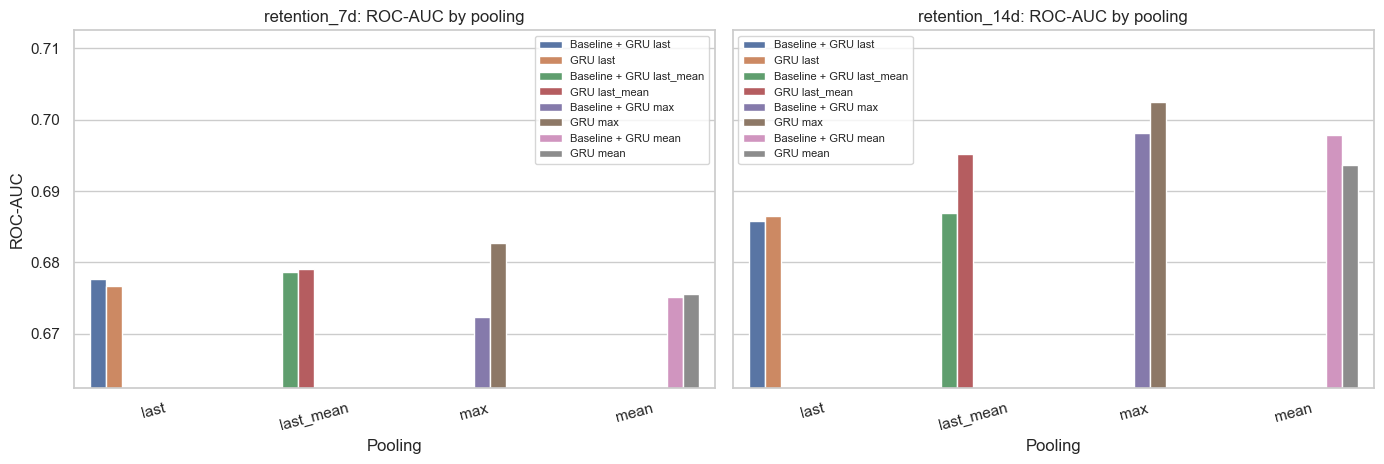

In [8]:
plot_df = test_metrics_df.filter(pl.col('feature_set') != 'Baseline')
plot_pdf = to_pandas(plot_df)

roc_min = plot_pdf['roc_auc'].min()
roc_max = plot_pdf['roc_auc'].max()
roc_pad = max(0.01, (roc_max - roc_min) * 0.25)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, label_name in zip(axes, ['retention_7d', 'retention_14d']):
    subset = plot_pdf[plot_pdf['label'] == label_name]
    sns.barplot(data=subset, x='pooling', y='roc_auc', hue='feature_set', ax=ax)
    ax.set_title(f'{label_name}: ROC-AUC by pooling')
    ax.set_xlabel('Pooling')
    ax.set_ylabel('ROC-AUC')
    ax.set_ylim(max(0.0, roc_min - roc_pad), min(1.0, roc_max + roc_pad))
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'pooling_roc_auc.png', dpi=180)
plt.show()

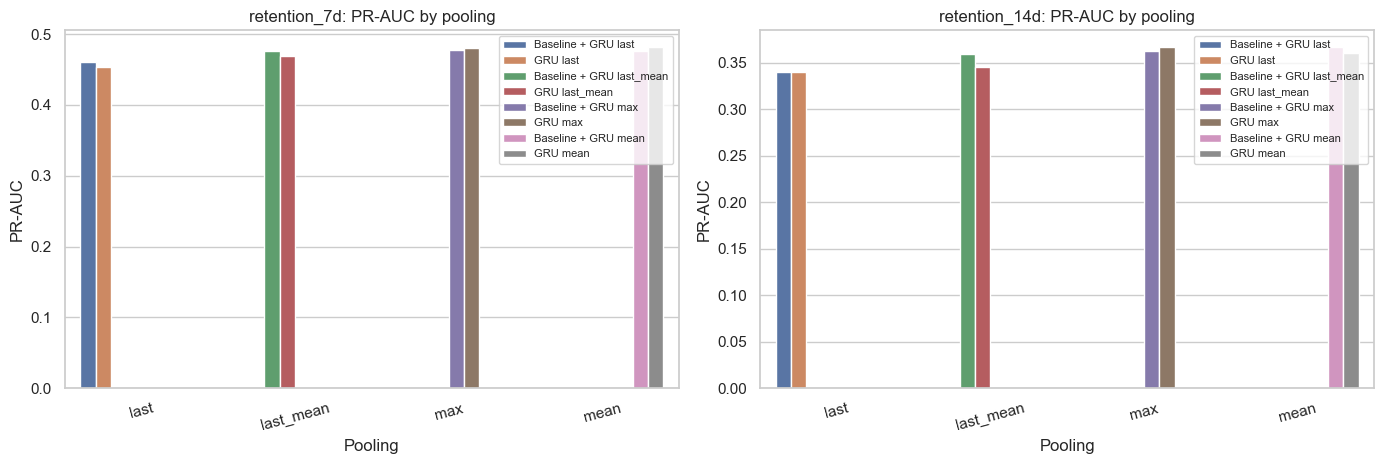

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=False)
for ax, label_name in zip(axes, ['retention_7d', 'retention_14d']):
    subset = plot_pdf[plot_pdf['label'] == label_name]
    sns.barplot(data=subset, x='pooling', y='pr_auc', hue='feature_set', ax=ax)
    ax.set_title(f'{label_name}: PR-AUC by pooling')
    ax.set_xlabel('Pooling')
    ax.set_ylabel('PR-AUC')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'pooling_pr_auc.png', dpi=180)
plt.show()

## 5. Диагностика embedding spaces

Помимо downstream-метрик, сравнивается геометрия самих embeddings. Это важно для темы курсовой: если pooling меняет структуру embedding space, это может быть содержательным результатом даже при близких downstream-метриках.

In [10]:
space_rows = []
projection_frames = []
metadata = (
    sequences_df.select(['appmetrica_device_id', 'sequence_len'])
    .join(baseline_df.select(['appmetrica_device_id', 'unique_event_count', 'repeat_ratio', 'prefix_active_days', 'retention_7d', 'retention_14d', 'split']), on='appmetrica_device_id', how='left')
)
metadata = build_activity_bucket(metadata)

sample_user_ids = metadata.sample(n=min(10_000, metadata.height), seed=SEED).select('appmetrica_device_id')

for strategy, bundle in embedding_sets.items():
    emb_df = bundle['df']
    emb_cols = bundle['cols']
    with_norm = add_embedding_norm(emb_df, emb_cols)
    pca_sample = sample_user_ids.join(with_norm, on='appmetrica_device_id', how='left')
    projection, pca_var = pca_projection(pca_sample, emb_cols, n_components=10, seed=SEED)
    projection_2d = projection.select(['appmetrica_device_id', 'pc_1', 'pc_2']).join(metadata, on='appmetrica_device_id', how='left').with_columns(pl.lit(strategy).alias('pooling'))
    projection_frames.append(projection_2d)

    assignments, inertia, silhouette = fit_kmeans(emb_df, emb_cols, n_clusters=N_CLUSTERS, seed=SEED)
    profile = cluster_profile(assignments, metadata).with_columns(pl.lit(strategy).alias('pooling'))
    profile.write_csv(OUT_DIR / f'cluster_profile_{strategy}.csv')

    space_rows.append(
        {
            'pooling': strategy,
            'embedding_dim': len(emb_cols),
            'mean_norm': float(with_norm['embedding_norm'].mean()),
            'std_norm': float(with_norm['embedding_norm'].std()),
            'pca10_cumulative_variance': float(np.cumsum(pca_var)[-1]),
            'kmeans_inertia': inertia,
            'kmeans_silhouette': silhouette,
            'cluster_retention_7d_min': float(profile['retention_7d_rate'].min()),
            'cluster_retention_7d_max': float(profile['retention_7d_rate'].max()),
            'cluster_median_seq_min': float(profile['median_sequence_len'].min()),
            'cluster_median_seq_max': float(profile['median_sequence_len'].max()),
        }
    )

pooling_space_summary_df = pl.DataFrame(space_rows).sort('pooling')
pooling_projection_df = pl.concat(projection_frames)
pooling_space_summary_df.write_csv(OUT_DIR / 'pooling_space_summary.csv')
pooling_projection_df.write_parquet(OUT_DIR / 'pooling_pca_projection_sample.parquet')
pooling_space_summary_df

pooling,embedding_dim,mean_norm,std_norm,pca10_cumulative_variance,kmeans_inertia,kmeans_silhouette,cluster_retention_7d_min,cluster_retention_7d_max,cluster_median_seq_min,cluster_median_seq_max
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""last""",128,8.485614,0.360573,0.584823,4.6140e6,0.15543,0.218126,0.436556,31.0,515.0
"""last_mean""",256,10.573669,0.445396,0.602614,9.7008e6,0.110508,0.182156,0.438244,22.0,492.0
"""max""",128,9.656616,0.577526,0.643053,4.4826e6,0.206322,0.153409,0.431797,17.0,576.0
"""mean""",128,6.296203,0.472269,0.760753,4.2822e6,0.146391,0.19457,0.437768,17.0,445.5


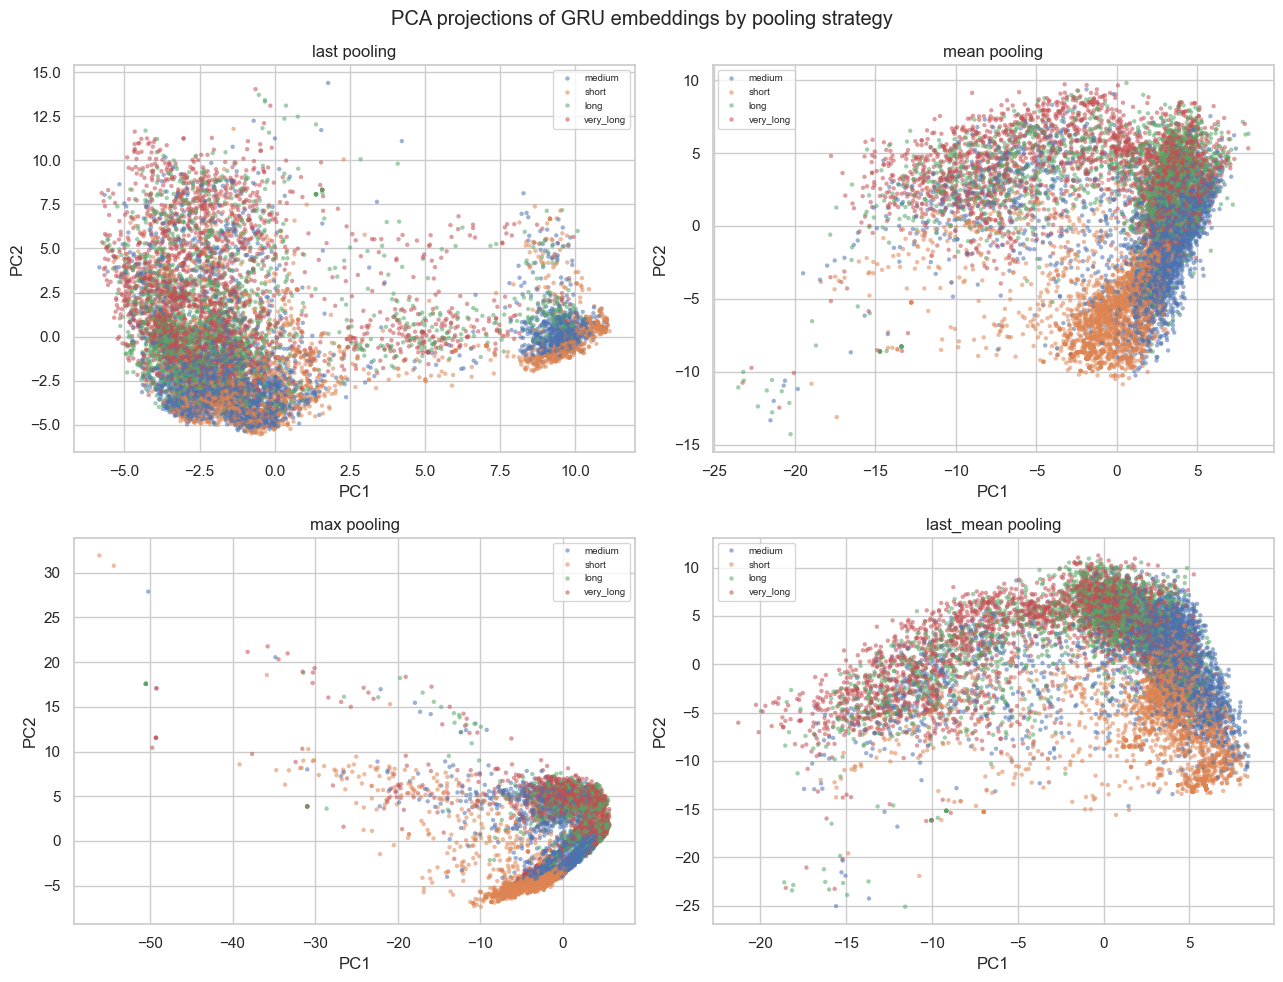

In [11]:
projection_pdf = to_pandas(pooling_projection_df)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()
for ax, strategy in zip(axes, POOLING_STRATEGIES):
    subset = projection_pdf[projection_pdf['pooling'] == strategy]
    sns.scatterplot(
        data=subset,
        x='pc_1',
        y='pc_2',
        hue='activity_bucket',
        s=10,
        alpha=0.55,
        linewidth=0,
        ax=ax,
    )
    ax.set_title(f'{strategy} pooling')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=7, frameon=True)
fig.suptitle('PCA projections of GRU embeddings by pooling strategy')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'pooling_pca_activity.png', dpi=180)
plt.show()

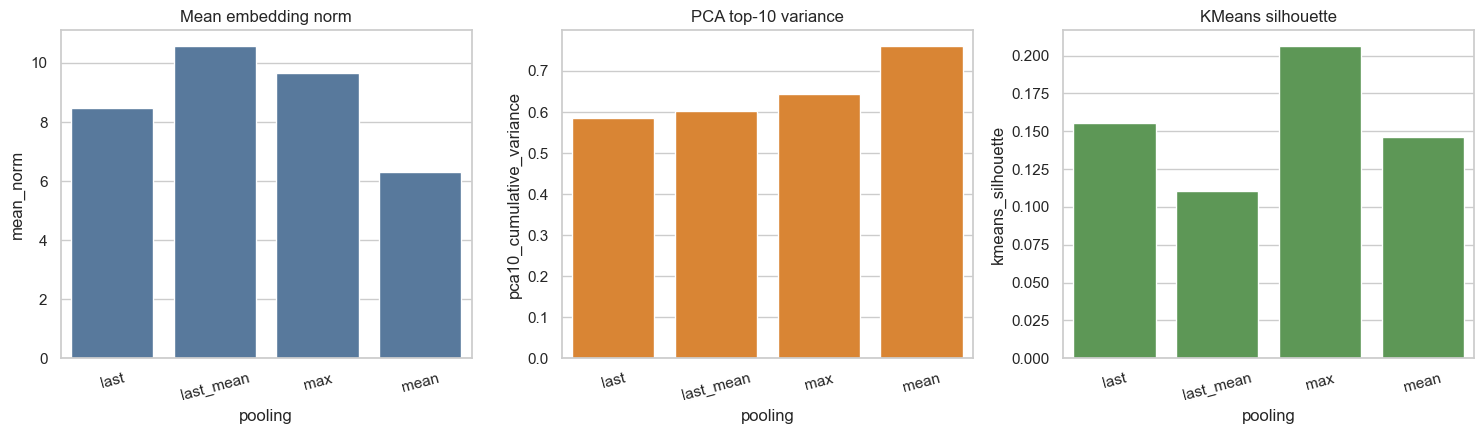

In [12]:
space_pdf = to_pandas(pooling_space_summary_df)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.barplot(data=space_pdf, x='pooling', y='mean_norm', ax=axes[0], color='#4C78A8')
axes[0].set_title('Mean embedding norm')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=space_pdf, x='pooling', y='pca10_cumulative_variance', ax=axes[1], color='#F58518')
axes[1].set_title('PCA top-10 variance')
axes[1].tick_params(axis='x', rotation=15)

sns.barplot(data=space_pdf, x='pooling', y='kmeans_silhouette', ax=axes[2], color='#54A24B')
axes[2].set_title('KMeans silhouette')
axes[2].tick_params(axis='x', rotation=15)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'pooling_space_diagnostics.png', dpi=180)
plt.show()

### Вывод по embedding-space диагностике

Pooling меняет не только retention-метрики, но и геометрию пространства. `mean` даёт наиболее компактное низкоразмерное описание по PCA (`0.761` top-10 variance), а `max` лучше выделяет кластерную структуру (`silhouette = 0.206`) и одновременно даёт лучшие downstream-метрики. Поэтому после нового split `max` выглядит не просто диагностически интересным, а основным кандидатом для финального pooling-варианта.


## Итог

Pooling ablation показал, что способ агрегации hidden states существенно влияет на качество RNN-эмбеддингов, причём этот вывод сохраняется в финальном downstream-протоколе с исключением коротких неполных историй.

Основные экспериментальные выводы:

- `last` pooling является рабочим базовым вариантом, но не лучшим. Для `retention_7d` чистый `GRU last` даёт test ROC-AUC `0.6766` и PR-AUC `0.4543`, тогда как `GRU max` даёт `0.6827 / 0.4800`, а `GRU mean` — `0.6756 / 0.4812`.
- Для `retention_14d` лучший ROC-AUC и PR-AUC среди всех pooling-вариантов у чистого `GRU max` (`0.7025 / 0.3663`). Ближайшие варианты — `Baseline + GRU max` (`0.6982 / 0.3627`) и `Baseline + GRU mean` (`0.6979 / 0.3663`).
- Комбинация с baseline не всегда улучшает чистый embedding. Например, на `retention_14d` `GRU max` имеет ROC-AUC `0.7025`, а `Baseline + GRU max` — `0.6982`; на `retention_7d` `GRU max` также выше комбинации с baseline по ROC-AUC (`0.6827` против `0.6724`). Это важный результат: RNN embedding сам по себе несёт сильный retention-сигнал.
- В embedding-space диагностике `mean` имеет самую высокую top-10 PCA variance (`0.761`), а `max` — лучший silhouette (`0.206`). Значит, pooling меняет не только downstream-метрики, но и структуру пространства пользовательских представлений.

Практический вывод этого этапа: для базового 128-мерного `GRU h128` лучшим pooling-вариантом является `max`. Он не увеличивает размерность, даёт лучший ROC-AUC на обеих retention-задачах и имеет наиболее выраженную кластерную структуру. Относительно tabular baseline это даёт прирост с `0.6639` до `0.6827` на `retention_7d` и с `0.6830` до `0.7025` на `retention_14d`.

`mean` стоит оставить как сильный альтернативный вариант по PR-AUC и PCA-компактности, а `last_mean` — скорее как отрицательный инженерный результат: он удваивает размерность до 256, но не даёт стабильного выигрыша. После этого ноутбука следующий вопрос уже не pooling, а capacity encoder'а; в `10` и `11` этот вывод уточняется до финального кандидата `GRU h256 l1 max`. Протокол в этом ноутбуке остаётся честным: embeddings строятся только по prefix events, labels считаются только для полностью наблюдаемого horizon, а downstream-модели обучаются только на train-пользователях.

In [13]:
config_out = {
    'seed': SEED,
    'prefix_len': PREFIX_LEN,
    'top_k_events': TOP_K_EVENTS,
    'horizons': HORIZONS,
    'pooling_strategies': POOLING_STRATEGIES,
    'batch_size': BATCH_SIZE,
    'n_clusters': N_CLUSTERS,
    'model_checkpoint': str((RNN_DIR / 'rnn_encoder.pt').relative_to(PROJECT_ROOT)),
}
(OUT_DIR / 'pooling_ablation_config.json').write_text(json.dumps(config_out, ensure_ascii=False, indent=2), encoding='utf-8')

saved_paths = {
    'metrics': OUT_DIR / 'pooling_downstream_metrics.csv',
    'space_summary': OUT_DIR / 'pooling_space_summary.csv',
    'embedding_summary': OUT_DIR / 'pooling_embedding_summary.csv',
    'figures': FIGURES_DIR,
    'embeddings': EMBEDDINGS_DIR,
    'config': OUT_DIR / 'pooling_ablation_config.json',
}
saved_paths

{'metrics': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/pooling_ablation/pooling_downstream_metrics.csv'),
 'space_summary': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/pooling_ablation/pooling_space_summary.csv'),
 'embedding_summary': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/pooling_ablation/pooling_embedding_summary.csv'),
 'figures': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/pooling_ablation/figures'),
 'embeddings': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/pooling_ablation/embeddings'),
 'config': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/pooling_ablation/pooling_ablation_config.json')}